In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd /Users/armandoroqueestrada/Proyecto_Proca/stability

/Users/armandoroqueestrada/Proyecto_Proca/Stability


In [3]:
import Modules.Background as bg
import numpy as np

import matplotlib.pyplot as plt
import Modules.Plot as cplot

In [4]:
cplot.general()

### Type of polarizations:

$i)$ $\gamma=0$, $\alpha=0$ if the polarization is linear, 

$ii)$ $\gamma=0$, $\alpha=1$ if the polarization is circular, and 

$iii)$ $\gamma=1$, $\alpha=0$ if the polarization is radial.


### Background solutions

Since we have scaling freedom, we only need to compute $\sigma_0 = 1$ and derive the rest from this.

\begin{align}
t \to \lambda_*^{-1} t, \quad \vec{x}\to \lambda_*^{-1/2} \vec{x},\quad U\to \lambda_x U, \quad \vec\psi \to \lambda_* \vec\psi
\end{align}

In [ ]:
s0val = [0.001, 0.01, 0.05, 0.1, 0.5, 0.8, 1, 1.2, 1.4, 1.6, 1.8, 2, 2.2, 2.4, 2.6, 2.8, 3, 3.2, 3.4, 3.6, 3.8, 4, 4.2, 4.4, 4.6, 4.8, 5]

Finding a profile with nodes: [0]
Final precision: U0 = [0.01694711] radius 168.9038092635562


/Users/armandoroqueestrada/Proyecto_Proca/Stability/Modules/Plot/plot_conf.py:345: UserWarning: The py, pz ccomponents was off because the number of fields is 1
  warnings.warn("The py, pz ccomponents was off because the number of fields is %d"%numFields)


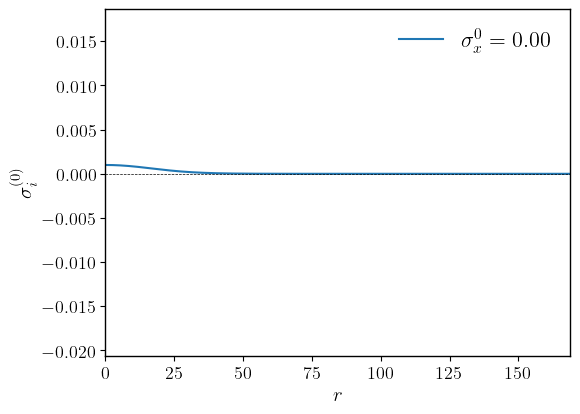

Finding a profile with nodes: [0]
Final precision: U0 = [0.07866151] radius 83.18194867730654


/Users/armandoroqueestrada/Proyecto_Proca/Stability/Modules/Plot/plot_conf.py:345: UserWarning: The py, pz ccomponents was off because the number of fields is 1
  warnings.warn("The py, pz ccomponents was off because the number of fields is %d"%numFields)


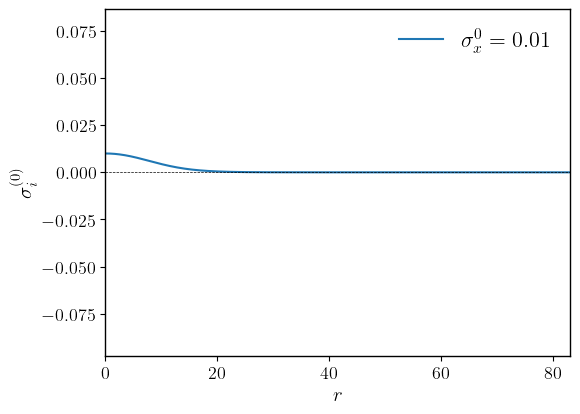

Finding a profile with nodes: [0]
Final precision: U0 = [0.23000766] radius 47.592575519029985


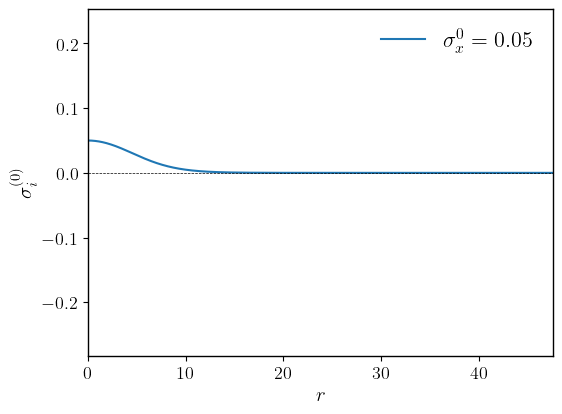

In [6]:
# EXAMPLE: Proca stars radially polarized Proca stars

LambT = 0 # autointeracción: 1 (repulsive), 0 (without selinteraction), -1 (attractive)

nx = 0  # node numbers: nx -> nodes of \sigma_x, ny  -> nodes of \sigma_y, ...
nodos = [nx]  # list of node info

p1x = 0  # The central amplitude of \sigma_x (p0x) and its first derivative value (p1x), the latter is zero
u1x = 0 # The first derivatives of the x.

Ini0 = [None, p1x, u1x]  # boundary conditions list
rmax = 5000  # iteration radius

# Range of values used as seed for the effective potential
Uxint = [0.00012057279119421096, 10]

met = 'DOP853'
gamma = 1  # gamma = 1 for radially polarized Proca stars

# IMPORTANT: the number of fields must be equal to the number of effective potential components
datos = []
for p0x in s0val:
    Ini0[0] = p0x
    Uintrs = [Uxint]
               
    numFields = len(Uintrs)
    Rtol = 1e-13 
    Atol = 1e-15

    u0Val, rTmax, events = bg.MultFreq_solveG2(Ini0, numFields=numFields, Uintrs=Uintrs, rmax=rmax, LambT=LambT, gamma=gamma, met=met,
                                                nodos=nodos, lim=1e-16, info=False, klim=5000, outval=0, delta=0., Rtol=Rtol, Atol=Atol)

    # plot the result
    U0 = np.zeros(4*numFields)
    U0[:2*numFields] = Ini0[:2*numFields]
    U0[2*numFields+1::2] = Ini0[2*numFields:]
    U0[2*numFields::2] = u0Val
    arg = [numFields, LambT, gamma]

    cplot.plotPerf(U0, rTmax, arg=arg)

    # f0, rmax, gamma, LambT, nodes, posNodes, met, Rtol, Atol, u0
    datos.append([U0[0], rTmax, gamma, LambT, nodos[0], None, met, Rtol, Atol, U0[2]])

Mass values: [0.948454975666088]
Eigenvalues of energy: [-0.024336505779474354]


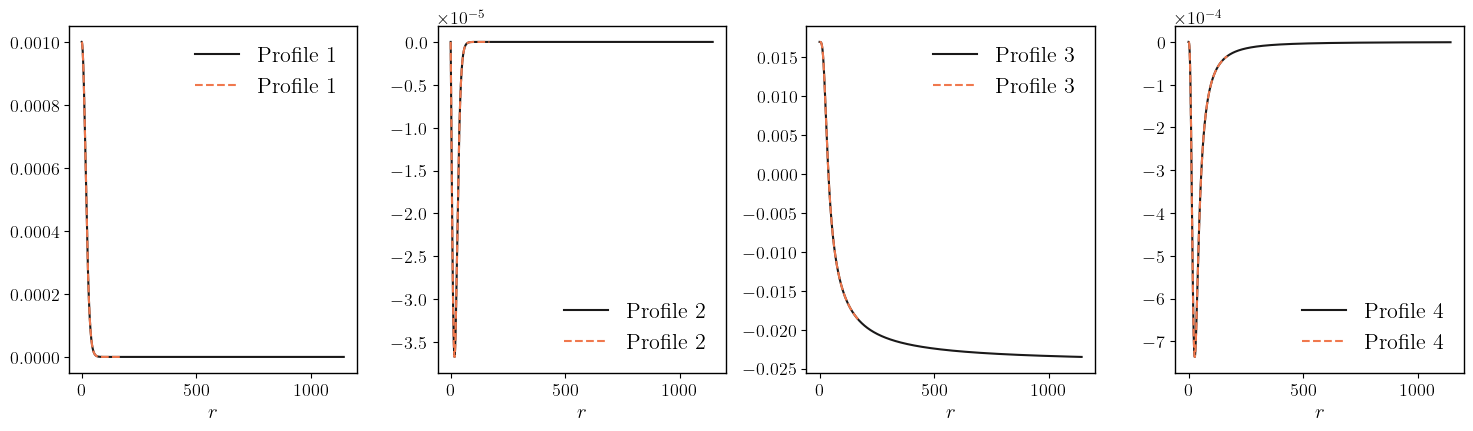

Mass values: [2.0433842869446717]
Eigenvalues of energy: [-0.1129600540523783]


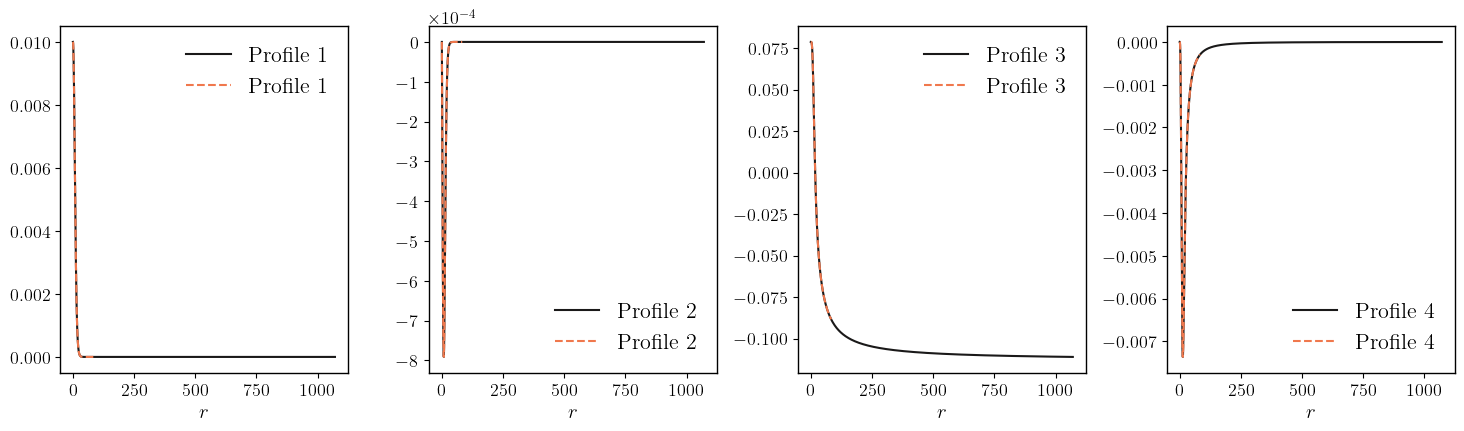

Mass values: [3.49413799058271]
Eigenvalues of energy: [-0.33029718443421663]


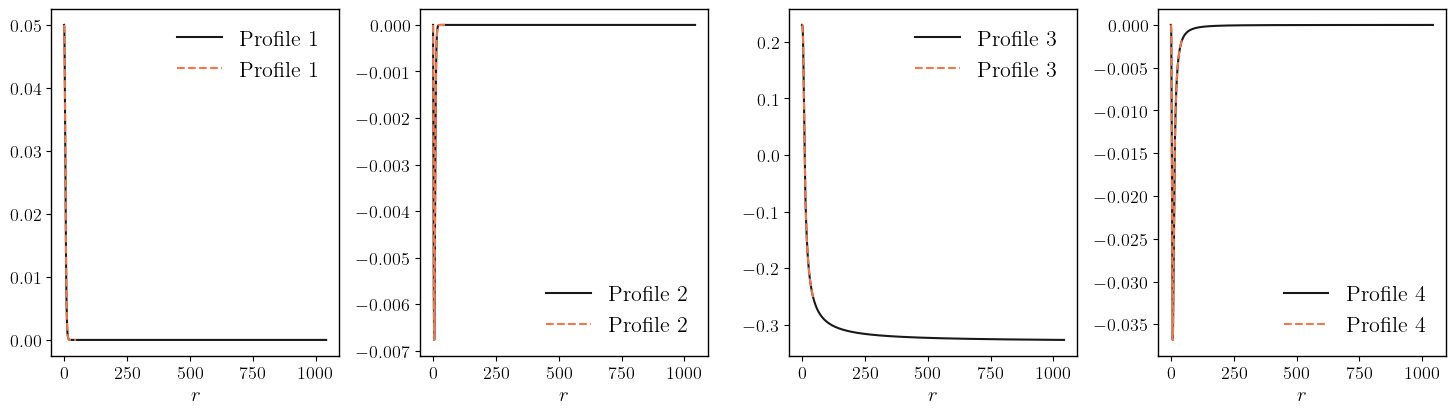

In [7]:
# Extendiendo los perfiles
Ext = 1000 #7000
Np = 1000 #int(2e06)

confidataEx = []
for confi in datos: # confidata datos
    dataEx = bg.mainExt(confi, mult=False, rmin=0, Nptos=Np, met='DOP853', metExp=1, info=True,
                    Rtol=1e-13, Atol=1e-15, deltaExt=Ext, yscale='linear', xscale='linear')  # out [[Ei, rDnew, sDnew, dsDnew, uDnew, duDnew], ..]
    confidataEx.append(dataEx[0])


In [ ]:
# Test scaling
# [[Ei, rDnew, sDnew, dsDnew, uDnew, duDnew], ..]
Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = confidataEx[0]
Ei1, rDnew1, sDnew1, dsDnew1, uDnew1, duDnew1 = confidataEx[1]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.0, wspace=.28))

ax[0].plot(rDnew, np.abs(sDnew), label=r'$\sigma_0=%2.1f$'%np.abs(sDnew)[0])
ax[0].plot(rDnew1, np.abs(sDnew1), label=r'$\sigma_0=%2.1f$'%np.abs(sDnew1)[0])
ax[0].legend(frameon=False)
ax[0].set_xlim(0, 50)
ax[0].set_yscale('log')
ax[0].set_ylim(1e-12, 10)

###########
ax[1].plot(rDnew1, rDnew1*sDnew1, label=r'$\sigma_0=%2.1f$'%np.abs(sDnew1)[0])

valmax = np.max(rDnew*sDnew)
valmax1 = np.max(rDnew1*sDnew1)
lambdaSt = valmax1/valmax

ax[1].plot(rDnew/np.sqrt(lambdaSt), (rDnew*sDnew)*lambdaSt, lw=1, label=r'$\sigma_0=%2.1f \times \lambda_*$'%np.abs(sDnew)[0])


ax[1].vlines(x=datos[0][3], ymin=1e-9, ymax=1, color='r', lw=0.5, ls='--')
ax[1].vlines(x=datos[1][3]*np.sqrt(lambdaSt), ymin=1e-9, ymax=1, color='k', lw=0.5, ls='-')

#ax[0].set_yscale('log')
#ax[1].set_yscale('log')
ax[1].set_ylim(-1., 2.01)
ax[1].legend(frameon=False)
ax[1].set_xlim(0, 35)

In [ ]:
print("lambda_* = ", lambdaSt)

Testeando los autovalores

In [8]:
import Modules.SpectralMeth as sp
from scipy.interpolate import interp1d

In [9]:
s0val

[0.001, 0.01, 0.05]

In [ ]:
polariz = 'radial'
nodos = 1

full_data = []
for data in confidataEx:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = data
    print('===> ', sDnew[0])

    datFunc = [
        [interp1d(rDnew, rDnew * sDnew)],
        [interp1d(rDnew, uDnew)]
        ]
    
    rMax = 200*(nodos+1) + 150
    Nptos = int(3*rMax/4) * 2

    Jval = [0, 1, 2, 3]
    lamV_list = [[0., 1.], [0., -1.]]   # ln, ls
    alp = 0.0

    # Graphing
    rad2 = np.linspace(0, rMax, 500000)
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

    ax[0].plot(rad2, datFunc[0][0](rad2))
    ax[1].plot(rad2, Ei - datFunc[1][0](rad2))
    ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
    ax[0].set_xlim(0, 30)
    #ax[0].set_ylim(-1, 1)
    # ax[0].set_yscale('log')
    plt.show()

    lambdaVal_s1, dataExtra_s1 = [], []
    for i in range(len(lamV_list)):
        lamV = lamV_list[i]
        lambdaVal, dataExtra = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
                Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)
        lambdaVal_s1.append(lambdaVal)
        dataExtra_s1.append(dataExtra)
    
    full_data.append([sDnew[0], lambdaVal_s1, dataExtra_s1])

In [ ]:
full_data_real = []
for data in full_data:
    s0, lambdaVal_s1, dataExtra_s1 = data
    print(s0, '/n', '#'*50)
    real_eigVal_s1LsP_list = []
    for i in range(len(lamV_list)):
        real_eigVal_s1LsP = []
        for ind, [Jval, data] in enumerate(dataExtra_s1[i]):
            rdis, eingVal, eigVect = data
            print('Jval = %d'%Jval)
            ind = np.abs(np.real(eingVal)) >= 1e-08 # filtrando los autovalores reales
            print(eingVal[ind])
            real_eigVal_s1LsP.append([Jval, eingVal[ind]])
        print('#'*50)
        real_eigVal_s1LsP_list.append([lamV_list[i], real_eigVal_s1LsP])

    full_data_real.append([s0, real_eigVal_s1LsP_list])


In [ ]:
np.save("Real_Eingevalues_rad_polarization_Lsn0", np.array(full_data_real, dtype=object))

### Test

In [ ]:
# s01 = np.load("background_data_profiles_free_case/sigma_0_1_rad.npy", allow_pickle=True)
#Ei1, rDnew1, sDnew1, dsDnew1, uDnew1, duDnew1 = s01

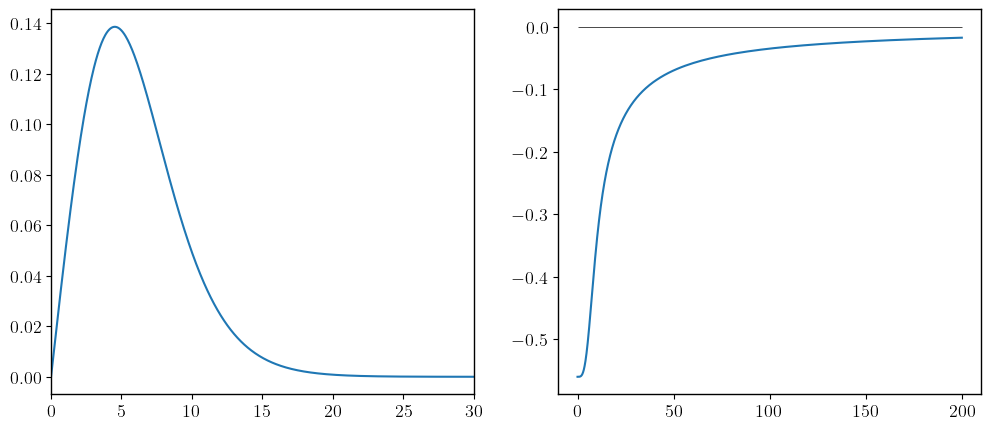

In [ ]:
Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = confidataEx[1]

polariz = 'radial'
datFunc = [
    [interp1d(rDnew, rDnew * sDnew)],
    [interp1d(rDnew, uDnew)],
]

nodos = 0
rMax = 200*(nodos+1) # - 30
Nptos = int(3*rMax/4) + 130

Jval = [0, 1, 2, 3]
lamV_list = [[0, 0], [0., 1.], [0., -1.]]   # ln, ls
alp = 0

# Graphing
rad2 = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

ax[0].plot(rad2, datFunc[0][0](rad2))
ax[1].plot(rad2, Ei - datFunc[1][0](rad2))
ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
#ax[0].set_yscale('log')
#ax[0].set_ylim(-1, 1)
plt.show()

lambdaVal_s1, dataExtra_s1 = [], []
for i in range(len(lamV_list)):
    lamV = lamV_list[i]
    lambdaVal, dataExtra = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)
    lambdaVal_s1.append(lambdaVal)
    dataExtra_s1.append(dataExtra)


In [15]:
real_eigVal_s1LsP_list = []
for i in range(len(lamV_list)):
    real_eigVal_s1LsP = []
    for ind, [Jval, data] in enumerate(dataExtra_s1[i]):
        rdis, eingVal, eigVect = data
        print('Jval = %d'%Jval)
        ind = np.abs(np.real(eingVal)) >= 1e-08 # filtrando los autovalores reales
        print(eingVal[ind])
        real_eigVal_s1LsP.append([Jval, eingVal[ind]])
    print('#'*50)
    real_eigVal_s1LsP_list.append([lamV_list[i], real_eigVal_s1LsP])


Jval = 0
[ 0.00074622-2.48488115e-15j -0.00074622-1.21130380e-16j]
Jval = 1
[]
Jval = 2
[-0.00014964-1.30887390e-13j  0.00014964-1.45834771e-13j]
Jval = 3
[]
##################################################
Jval = 0
[ 0.00074622-2.48488115e-15j -0.00074622-1.21130380e-16j
 -0.0031185 +8.00305205e-02j  0.0031185 +8.00305205e-02j
  0.0031185 +8.00305205e-02j -0.0031185 +8.00305205e-02j
  0.0031185 -8.00305205e-02j -0.0031185 -8.00305205e-02j
  0.0031185 -8.00305205e-02j -0.0031185 -8.00305205e-02j]
Jval = 1
[]
Jval = 2
[-0.0251118-7.39880135e-14j  0.0251118-7.41789755e-14j]
Jval = 3
[]
##################################################
Jval = 0
[ 0.00074622-2.48488115e-15j -0.00074622-1.21130380e-16j]
Jval = 1
[ 9.95750211e-05+3.81119397e-15j -9.95750211e-05+5.11221080e-15j]
Jval = 2
[]
Jval = 3
[]
##################################################


### Stability 

In [176]:
Real_Eingevalues_rad_polarization_Lsn0 = np.load("stability_lambda_s_case/Polarization_radial/Real_Eingevalues_rad_polarization_Lsn0.npy", allow_pickle=True)

In [177]:
lambda_data = {'1': [], '-1': []}  # [[ls=1, [s0, ]], [ls=-1, [s0, ]]]
for dat_ in Real_Eingevalues_rad_polarization_Lsn0:
    temp = [[], []]
    s0, real_eigVal_list = dat_
    temp[0].append(s0); temp[1].append(s0)
    for i, dat2_ in enumerate(real_eigVal_list):
        lamV, real_eigVal = dat2_
        temp[i].append(real_eigVal)
    lambda_data['1'].append(temp[0])
    lambda_data['-1'].append(temp[1])

In [178]:
# Filtrando datos
from collections import defaultdict

def dividir_ramas(datos):
    ramas = defaultdict(list)

    # Agrupar por x
    grupos = defaultdict(list)
    for x, y in datos:
        grupos[x].append(y)

    # Ordenar y asignar a ramas
    for x in sorted(grupos.keys()):  # mantiene orden creciente en x
        # ys = sorted([y for y in grupos[x] if y is not None], reverse=True)
        ys = sorted(grupos[x], reverse=True)  # mayor a menor
        for idx, y in enumerate(ys):
            ramas[idx].append([x, y])

    # Convertir a lista de listas
    return [ramas[k] for k in sorted(ramas.keys())]

In [179]:
len(lambda_data['1'])

27

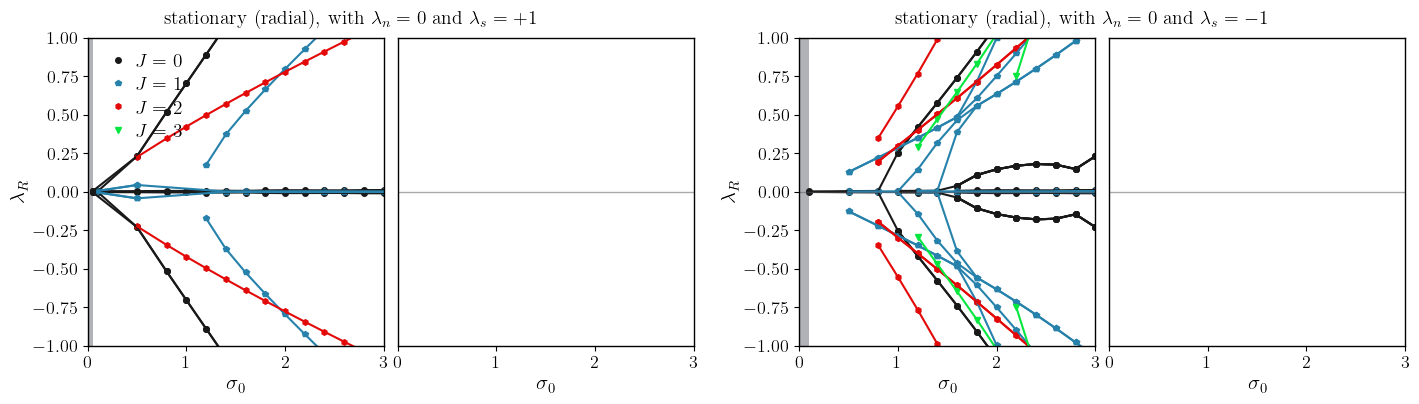

In [197]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(17, 4.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.5, wspace=.15) # espacio vertical y horizontal entre los subplots
                      )

# [Jval_temp, s0, r, eingVal, eigVect]
tempP, tempN = {'0': [], '1': [], '2': [], '3': [], '4': [], '5': []}, {'0': [], '1': [], '2': [], '3': [], '4': [], '5': []}
for dataExtra in [lambda_data['1']]:
      for cont, [s0, dat_] in enumerate(dataExtra):
           for cond2, [Jval_temp, eingVal] in enumerate(dat_):
               if Jval_temp == 2:
                    ind = np.abs(np.real(eingVal)) >= 6e-02
               else:
                    ind = np.abs(np.real(eingVal)) >= 1e-03 # filtrando los autovalores reales
               y = eingVal[ind]
               x = [s0] * len(y)
               if cont == 0:
                    ax[0].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
               else:
                    ax[0].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)
               
               if len(y) == 0:
                    y = [None]

               for mod in np.real(y):
                   if mod is None or mod > 0:
                       tempP[str(Jval_temp)].append([s0, mod])
                   if mod is None or mod < 0:
                       tempN[str(Jval_temp)].append([s0, mod])

ax[0].legend(frameon=False, fontsize=14, ncols=1, columnspacing=1.5, handletextpad=0.2, handlelength=1.5, labelspacing=0.3, borderpad=0.3)

for cond2, key in enumerate(tempP.keys()):
    tempP[key] = np.array(tempP[key], dtype=object)
    # tempN[key] = np.array(tempN[key], dtype=object)
    plot_branch_P = dividir_ramas(tempP[key])
    # plot_branch_N = dividir_ramas(tempN[key])
    for i in range(len(plot_branch_P)):
        ax[0].plot(np.array(plot_branch_P[i])[:,0], np.array(plot_branch_P[i])[:, 1], color=col[cond2])
        arr_neg = np.array([x * -1 if x is not None else None for x in np.array(plot_branch_P[i])[:, 1]], dtype=object)
        ax[0].plot(np.array(plot_branch_P[i])[:, 0], arr_neg, color=col[cond2])

###################################
tempP, tempN = {'0': [], '1': [], '2': [], '3': [], '4': [], '5': []}, {'0': [], '1': [], '2': [], '3': [], '4': [], '5': []}
for dataExtra in [lambda_data['-1']]:
      for cont, [s0, dat_] in enumerate(dataExtra):
           for cond2, [Jval_temp, eingVal] in enumerate(dat_):
               if Jval_temp == 2:
                    ind = np.abs(np.real(eingVal)) >= 6e-02
               else:
                    ind = np.abs(np.real(eingVal)) >= 1e-03 # filtrando los autovalores reales
               y = eingVal[ind]
               x = [s0] * len(y)
               if cont == 0:
                    ax[2].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
               else:
                    ax[2].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)
               
               if len(y) == 0:
                    y = [None]

               for mod in np.real(y):
                   if mod is None or mod > 0:
                       tempP[str(Jval_temp)].append([s0, mod])
                   if mod is None or mod < 0:
                       tempN[str(Jval_temp)].append([s0, mod])

for cond2, key in enumerate(tempP.keys()):
    tempP[key] = np.array(tempP[key], dtype=object)
    # tempN[key] = np.array(tempN[key], dtype=object)
    plot_branch_P = dividir_ramas(tempP[key])
    # plot_branch_N = dividir_ramas(tempN[key])
    for i in range(len(plot_branch_P)):
        ax[2].plot(np.array(plot_branch_P[i])[:,0], np.array(plot_branch_P[i])[:, 1], color=col[cond2])
        arr_neg = np.array([x * -1 if x is not None else None for x in np.array(plot_branch_P[i])[:, 1]], dtype=object)
        ax[2].plot(np.array(plot_branch_P[i])[:, 0], arr_neg, color=col[cond2])


#############

ax[1].set_yticks([])
ax[3].set_yticks([])
ax[0].set_ylabel(r'$\lambda_{R}$')
ax[2].set_ylabel(r'$\lambda_{R}$')


# Añadir una etiqueta para el marco exterior
fig.text(
    x=0.28, y=0.95,                    # posición (x, y) relativa a la figura
    s=r'stationary (radial), with $\lambda_n= 0$ and $\lambda_s=+1$',          # texto
    ha='center', va='top',        # alineación horizontal y vertical
    fontsize=14, color='k',
    weight='bold'
)


fig.text(
    x=0.71, y=0.95,                    # posición (x, y) relativa a la figura
    s=r'stationary (radial), with $\lambda_n= 0$ and $\lambda_s=-1$',          # texto
    ha='center', va='top',        # alineación horizontal y vertical
    fontsize=14, color='k',
    weight='bold'
)

# Obtener posiciones originales
pos2 = ax[1].get_position()
pos3 = ax[2].get_position()

# Acercar la segunda y tercera columna
ax[1].set_position([pos2.x0 - 0.018, pos2.y0, pos2.width, pos2.height])
ax[2].set_position([pos3.x0 + 0.018, pos3.y0, pos3.width, pos3.height])

for axes in ax:
    axes.set_xlim(0, 3)
    axes.set_ylim(-1., 1.)
    axes.set_xlabel(r'$\sigma_0$')


#ax[0].hlines(y=0, xmin=0, xmax=3.3, ls='-', lw=1, color='#55555e', alpha=0.5)
#ax[0].hlines(y=0, xmin=7.4, xmax=11.5, ls='-', lw=1, color='#55555e', alpha=0.5)

ax[1].hlines(y=0, xmin=0, xmax=11.5, ls='-', lw=1, color='#55555e', alpha=0.5)
ax[2].hlines(y=0, xmin=0, xmax=11.5, ls='-', lw=1, color='#55555e', alpha=0.5)
ax[3].hlines(y=0, xmin=0, xmax=50, ls='-', lw=1, color='#55555e', alpha=0.5)

#ax[0].text(3.5, -0.03, s=r'stable band', rotation='horizontal')#, fontsize='small'

ax[0].axvspan(0, 0.05, facecolor='#656473', alpha=0.5)
ax[2].axvspan(0, 0.1, facecolor='#656473', alpha=0.5)
#ax[2].axvspan(0, 1.046, facecolor='#656473', alpha=0.5)
#ax[2].text(0.25, .25, s=r'stable band', rotation='vertical')#, fontsize='small'


In [196]:
lambda_data['-1']

[[0.001,
  [[0,
    array([ 4.37094791e-05-3.75169603e-15j, -4.37094791e-05-3.75255080e-15j])],
   [1,
    array([ 1.55831885e-06+7.78789335e-16j, -1.55831885e-06+7.61040622e-16j])],
   [2, array([], dtype=complex128)],
   [3, array([], dtype=complex128)]]],
 [0.01,
  [[0, array([-0.00024137+1.59407616e-14j,  0.00024137+4.01172868e-15j])],
   [1,
    array([ 1.84646566e-05+1.32466920e-14j, -1.84646566e-05-5.84454666e-15j])],
   [2, array([], dtype=complex128)],
   [3, array([], dtype=complex128)]]],
 [0.05,
  [[0, array([ 0.00068166+2.29830047e-13j, -0.00068166-3.38341178e-14j])],
   [1,
    array([ 9.01838746e-05+2.03415018e-13j, -9.01838746e-05-1.83528411e-13j])],
   [2, array([], dtype=complex128)],
   [3, array([], dtype=complex128)]]],
 [0.1,
  [[0, array([-0.0011581+4.50463039e-13j,  0.0011581-1.68664561e-13j])],
   [1, array([-0.00019567+1.38612678e-12j,  0.00019567-1.47728979e-12j])],
   [2, array([], dtype=complex128)],
   [3, array([], dtype=complex128)]]],
 [0.5,
  [[0, arra